<a href="https://colab.research.google.com/github/yadavrishikesh/Masterclass-IITMandi/blob/main/Module2/assignment/Lab2_Assignment_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task1: Time‑Series Analysis of Precipitation
Note: Do the tasks under Task 1 using any of the grid cell(lat-lon) data (not on whole grid)

##1.1 Load & Inspect

Read data into a DataFrame.

Display head and check for missing values.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # data visualization
import seaborn as sns

In [ ]:
import requests
import pandas as pd
import io

# GitHub API URL to list contents of a directory
api_url = "https://api.github.com/repos/yadavrishikesh/Masterclass-IITMandi/contents/Module1/data/PREC"

# Base URL for raw CSV content
raw_base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PREC/"

# Get list of all CSV files ending with '_pdata.csv'
response = requests.get(api_url)
if response.status_code != 200:
    raise Exception("Failed to fetch file list from GitHub API.")

files = response.json()
csv_file_names = [file['name'] for file in files if file['name'].endswith('_pdata.csv')]

# Load and merge data
all_dfs = []
base_lat = None
base_lon = None

for file_name in csv_file_names:
    url = raw_base_url + file_name
    try:
        res = requests.get(url)
        res.raise_for_status()
        df = pd.read_csv(io.StringIO(res.text))
        df = df.rename(columns={'lat_cell': 'lat', 'lon_cell': 'lon'})

        year = file_name.replace('_pdata.csv', '')
        # Extract the main variable column to rename uniquely
        new_column_names = {}
        for col in df.columns:
            if col not in ['lat', 'lon']:
              if len(col) <= 2 and col.isdigit(): # Check if it's a month number like '01'
                    new_column_names[col] = f"{year}-{col}"
              else: # Assume it's already in a desired format like '2010-01'
                    new_column_names[col] = col

        df.rename(columns=new_column_names, inplace=True)
        # Remove lat/lon after saving them from the first file
        if base_lat is None:
            base_lat = df['lat']
            base_lon = df['lon']
        df = df.drop(columns=['lat', 'lon'])

        all_dfs.append(df)

    except Exception as e:
        print(f"Skipping {file_name} due to error: {e}")

# Concatenate all data columns and add lat/lon back
if all_dfs:
    # Concatenate all dataframes along axis 1 (columns)
    merged_df = pd.concat(all_dfs, axis=1)
    # Add lat and lon back as the first two columns
    merged_df.insert(0, 'lon', base_lon)
    merged_df.insert(0, 'lat', base_lat)

    merged_df.to_csv('merged_precipitation_data.csv', index=False)
    print("✅ Merged data saved as 'merged_precipitation_data.csv'")
    print("Shape:", merged_df.shape)
    print(merged_df.head())
else:
    print("❌ No data was merged.")

✅ Merged data saved as 'merged_precipitation_data.csv'
Shape: (255, 170)
    lat     lon       2010-01       2010-02       2010-03       2010-04  \
0  29.0  72.500  2.026437e-10  9.148820e-06  4.523785e-10  4.593997e-07   
1  29.0  73.125  8.330295e-07  6.156963e-06  1.334666e-10  1.946300e-08   
2  29.0  73.750  9.271720e-06  2.772628e-06  1.404082e-10  1.871002e-10   
3  29.0  74.375  4.745409e-06  9.780649e-07  1.031488e-10  5.479517e-12   
4  29.0  75.000  1.246014e-07  1.386647e-06  3.084629e-11  1.991351e-12   

        2010-05   2010-06   2010-07   2010-08  ...   2023-03   2023-04  \
0  9.694044e-09  0.000012  0.000096  0.000080  ...  0.000043  0.000032   
1  1.006603e-08  0.000031  0.000202  0.000090  ...  0.000037  0.000026   
2  4.591385e-11  0.000033  0.000164  0.000119  ...  0.000058  0.000019   
3  7.971506e-12  0.000016  0.000143  0.000182  ...  0.000051  0.000018   
4  1.424704e-11  0.000032  0.000166  0.000236  ...  0.000032  0.000023   

    2023-05   2023-06   2023-07

In [ ]:
print("\nMissing values after merge:")
print(merged_df.isnull().sum().sort_values(ascending=False))


Missing values after merge:
lat        0
lon        0
2010-01    0
2010-02    0
2010-03    0
          ..
2023-08    0
2023-09    0
2023-10    0
2023-11    0
2023-12    0
Length: 170, dtype: int64


In [ ]:
# Identify the date columns
date_cols = [col for col in merged_df.columns if col not in ['lat', 'lon']]

# Convert the kg/m2/s to mm/month
merged_df[date_cols] = merged_df[date_cols] * 2629800

print("\nDataFrame after converting precipitation to mm:")
print(merged_df.head())


DataFrame after converting precipitation to mm:
    lat     lon    2010-01    2010-02   2010-03   2010-04   2010-05  \
0  29.0  72.500   0.000533  24.059567  0.001190  1.208129  0.025493   
1  29.0  73.125   2.190701  16.191583  0.000351  0.051184  0.026472   
2  29.0  73.750  24.382769   7.291456  0.000369  0.000492  0.000121   
3  29.0  74.375  12.479476   2.572115  0.000271  0.000014  0.000021   
4  29.0  75.000   0.327677   3.646604  0.000081  0.000005  0.000037   

     2010-06     2010-07     2010-08  ...     2023-03    2023-04     2023-05  \
0  32.239147  252.763148  210.426524  ...  113.328838  85.208360  500.601654   
1  82.665743  530.015309  237.078429  ...   97.447612  67.339758  293.129211   
2  85.974326  431.141194  313.903211  ...  151.444168  49.239002   71.702891   
3  43.315709  375.642315  478.137061  ...  134.818659  46.375003   67.083587   
4  84.304961  436.949869  620.815834  ...   83.046949  59.447723   95.928522   

      2023-06      2023-07    2023-08     2

##1.2 Visualize the Series

For one representative grid cell (pick a lat‑lon), plot monthly precip over time.

Use a rolling mean (window=12) to highlight seasonal cycles.

/tmp/ipython-input-5-3028386573.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_precip = precip_df['Precipitation'].resample('M').sum()


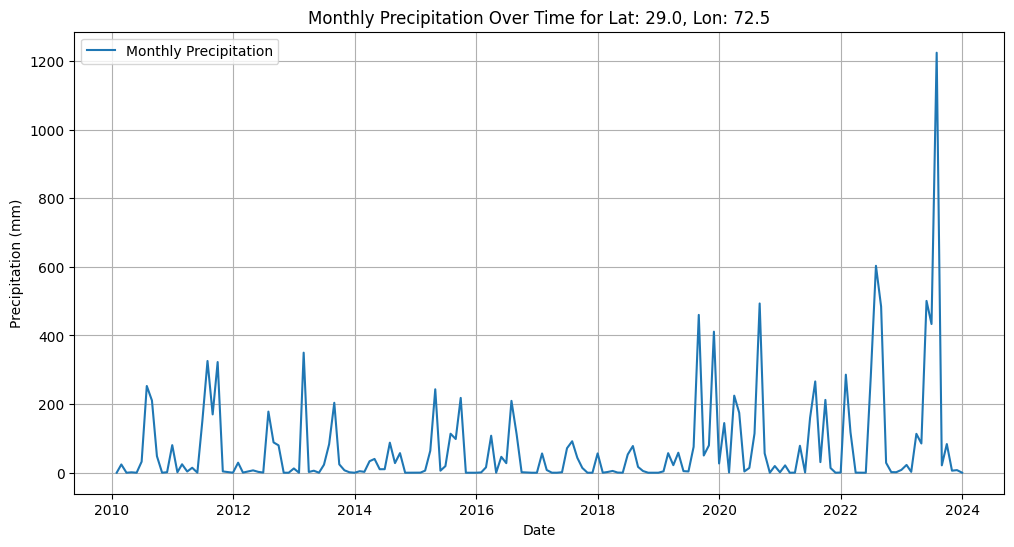

In [ ]:
# Choose a representative grid cell (e.g., the first one in the DataFrame)
representative_cell = merged_df.iloc[0]
lat_cell = representative_cell['lat']
lon_cell = representative_cell['lon']

# Extract the precipitation data for this cell
precip_data = representative_cell[date_cols]

# Convert the index (dates) to datetime objects
# Changed the format string to match 'YYYY-MM'
precip_data.index = pd.to_datetime(precip_data.index, format='%Y-%m')

# Create a new DataFrame with the precipitation data and the datetime index
precip_df = pd.DataFrame({'Precipitation': precip_data})
# Resample to monthly data and sum the precipitation for each month
monthly_precip = precip_df['Precipitation'].resample('M').sum()

# Plot the monthly precipitation
plt.figure(figsize=(12, 6))
plt.plot(monthly_precip.index, monthly_precip.values, label='Monthly Precipitation')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.title(f'Monthly Precipitation Over Time for Lat: {lat_cell}, Lon: {lon_cell}')
plt.grid(True)
plt.legend()
plt.show()

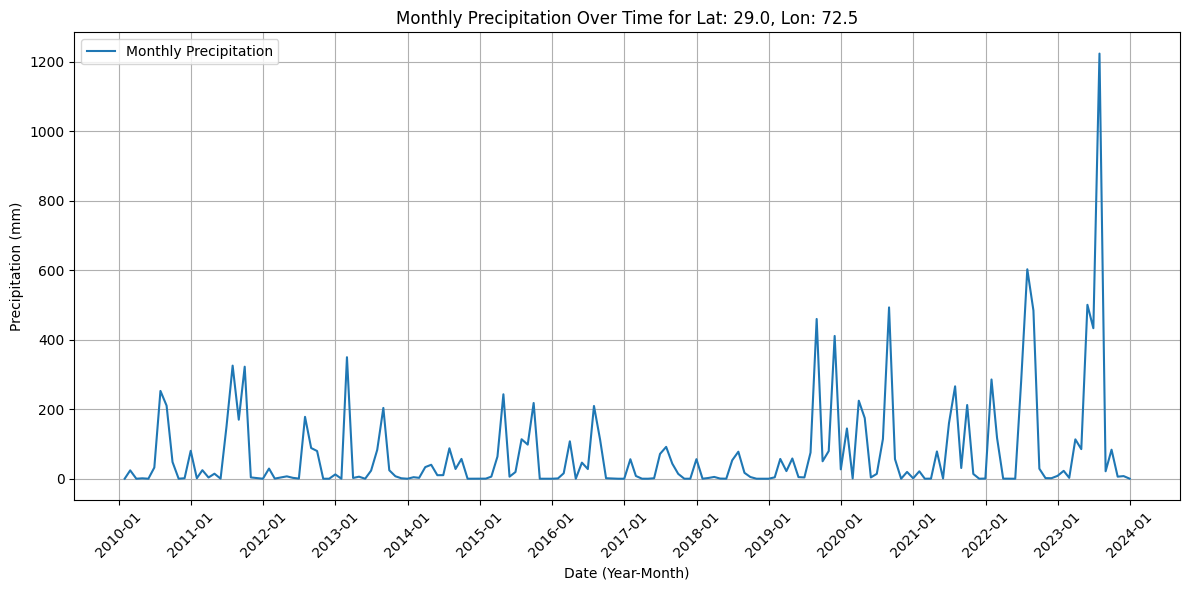

In [ ]:
import matplotlib.dates as mdates
plt.figure(figsize=(12, 6))
plt.plot(monthly_precip.index, monthly_precip.values, label='Monthly Precipitation')
plt.xlabel('Date (Year-Month)') # Update the xlabel to reflect the format
plt.ylabel('Precipitation (mm)')
plt.title(f'Monthly Precipitation Over Time for Lat: {lat_cell}, Lon: {lon_cell}')

# Use matplotlib.dates to format the x-axis
ax = plt.gca() # Get the current axes
ax.xaxis.set_major_locator(mdates.YearLocator()) # Set a locator for years (optional, adjust as needed)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Format the date as Year-Month
plt.xticks(rotation=45) # Rotate the x-axis labels for better readability

plt.grid(True)
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

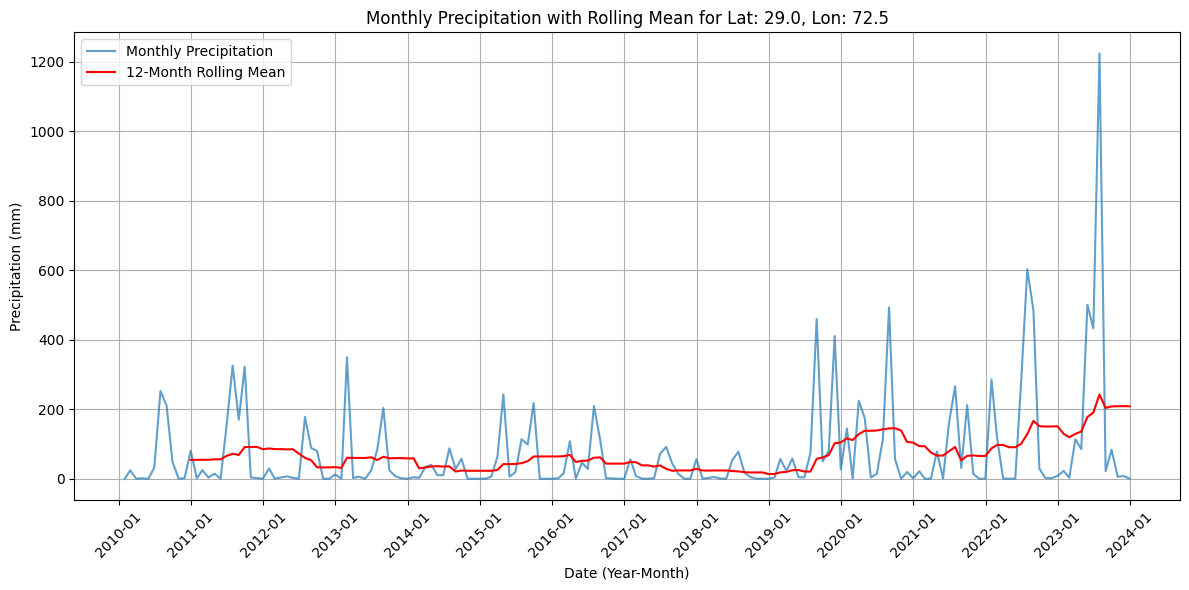

In [ ]:
# Calculate the 12-month rolling mean
rolling_mean = monthly_precip.rolling(window=12).mean()

# Plot the original monthly precipitation and the rolling mean
plt.figure(figsize=(12, 6))
plt.plot(monthly_precip.index, monthly_precip.values, label='Monthly Precipitation', alpha=0.7)
plt.plot(rolling_mean.index, rolling_mean.values, label='12-Month Rolling Mean', color='red')

plt.xlabel('Date (Year-Month)') # Update the xlabel to reflect the format
plt.ylabel('Precipitation (mm)')
plt.title(f'Monthly Precipitation with Rolling Mean for Lat: {lat_cell}, Lon: {lon_cell}')

# Use matplotlib.dates to format the x-axis
ax = plt.gca() # Get the current axes
ax.xaxis.set_major_locator(mdates.YearLocator()) # Set a locator for years (optional, adjust as needed)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Format the date as Year-Month
plt.xticks(rotation=45) # Rotate the x-axis labels for better readability

plt.grid(True)
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

##1.3 Decomposition

Decompose the same single‑cell series into trend, seasonal, and residual components (e.g. via statsmodels.tsa.seasonal_decompose).

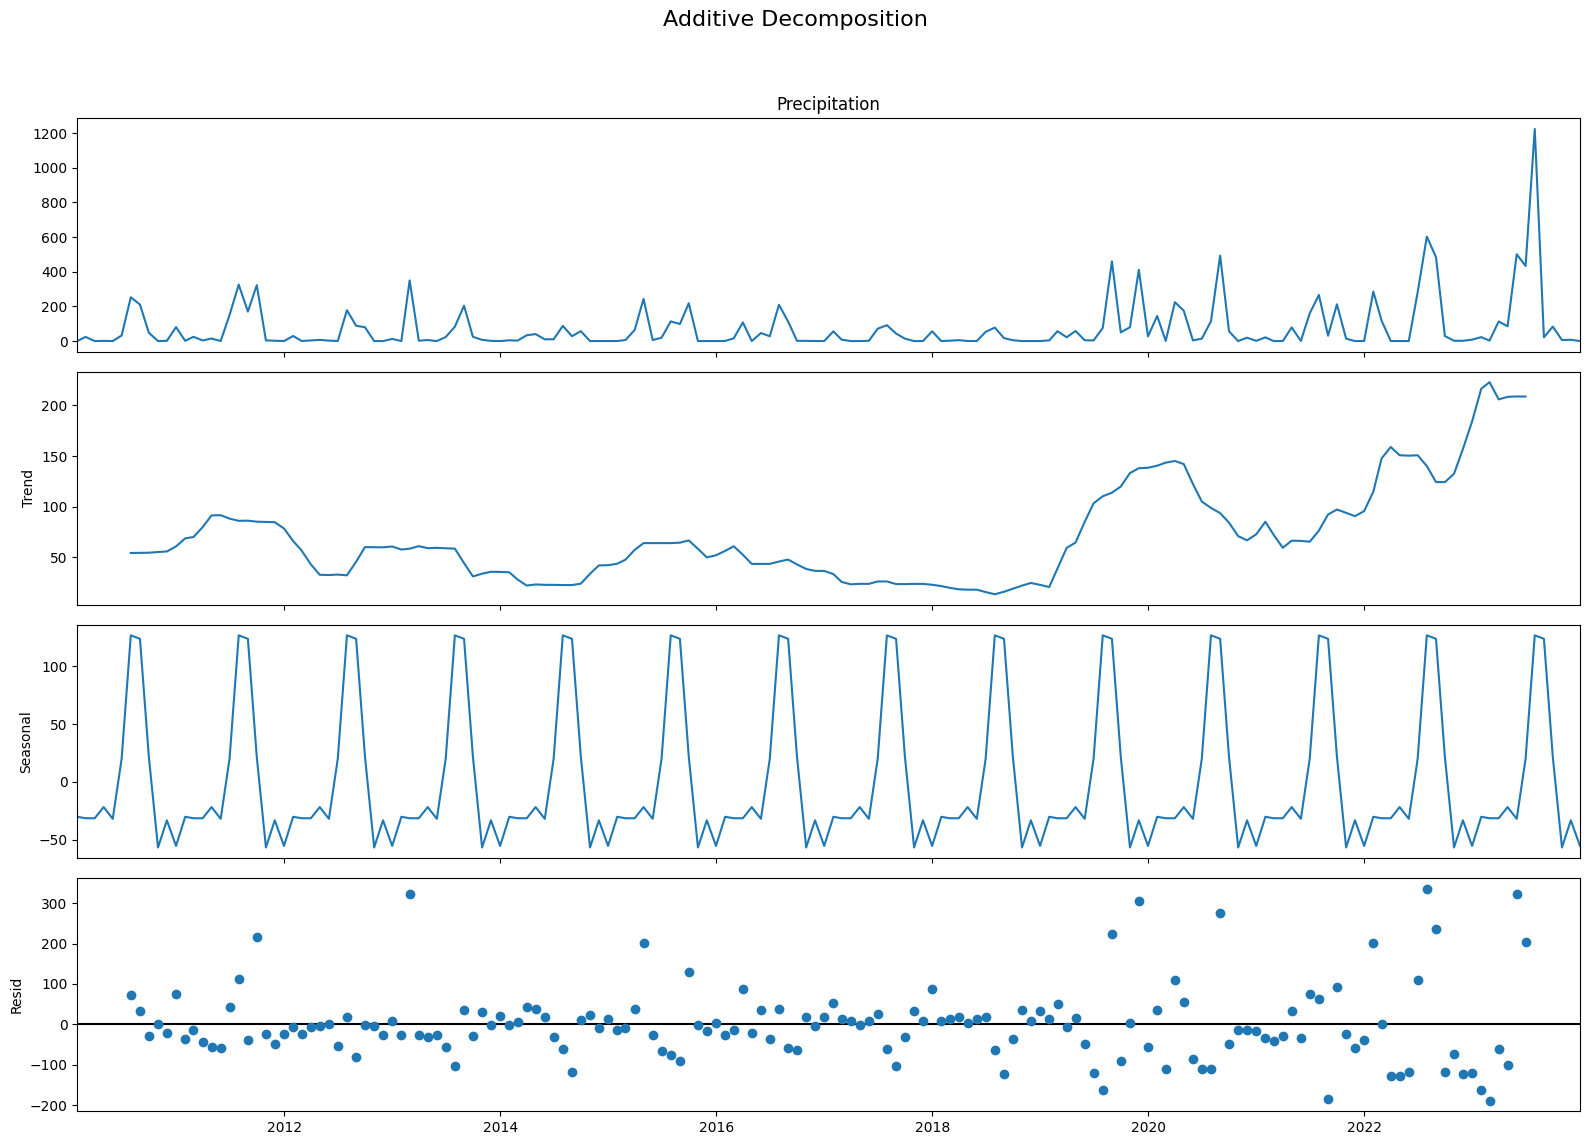

Multiplicative decomposition skipped due to non-positive values in the time series.


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse
# For monthly data, the period is 12
decomposition_period = 12

# Additive Decomposition
additive_decomposition = seasonal_decompose(monthly_precip, model='additive', period=decomposition_period)

# Plot
plt.rcParams.update({'figure.figsize': (16, 12)})

# Plot Additive Decomposition
fig_add = additive_decomposition.plot()
fig_add.suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Multiplicative Decomposition (Optional, if data is suitable)
# Check if all values are strictly positive for multiplicative decomposition
if (monthly_precip > 0).all():
    multiplicative_decomposition = seasonal_decompose(monthly_precip, model='multiplicative', period=decomposition_period)

    # Plot Multiplicative Decomposition
    fig_mult = multiplicative_decomposition.plot()
    fig_mult.suptitle('Multiplicative Decomposition', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Multiplicative decomposition skipped due to non-positive values in the time series.")

## 1.4 Stationarity Tests

Apply Augmented Dickey–Fuller (ADF) and KPSS tests.

Interpret p‑values: is the raw series stationary? If not, how many differences are needed?

Converting Non-Stationary time serie to Stationary (USING DIFFERENCING)

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
adf_test = adfuller(monthly_precip)

# Extract and print results
adf_statistic = adf_test[0]
p_value = adf_test[1]
critical_values = adf_test[4]

print('ADF Statistic: %f' % adf_statistic)
print('p-value: %f' % p_value)
print('Critical Values:')
for key, value in critical_values.items():
    print('\t%s: %.3f' % (key, value))

# Interpret the results
if p_value <= 0.05:
    print("The p-value is less than or equal to 0.05. Reject the null hypothesis. The series is likely stationary.")
else:
    print("The p-value is greater than 0.05. Fail to reject the null hypothesis. The series is likely non-stationary.")

ADF Statistic: -0.307129
p-value: 0.924489
Critical Values:
	1%: -3.473
	5%: -2.880
	10%: -2.577
The p-value is greater than 0.05. Fail to reject the null hypothesis. The series is likely non-stationary.


In [ ]:
from statsmodels.tsa.stattools import kpss

# Perform KPSS test
kpss_test = kpss(monthly_precip, regression='c')

# Extract and print results
kpss_statistic = kpss_test[0]
p_value_kpss = kpss_test[1]
critical_values_kpss = kpss_test[3]

print('\nKPSS Statistic: %f' % kpss_statistic)
print('p-value: %f' % p_value_kpss)
print('Critical Values:')
for key, value in critical_values_kpss.items():
    print('\t%s: %.3f' % (key, value))

# Interpret the results (KPSS null hypothesis: the series is stationary around a mean/trend)
if p_value_kpss <= 0.05:
    print("The p-value is less than or equal to 0.05. Reject the null hypothesis. The series is likely non-stationary.")
else:
    print("The p-value is greater than 0.05. Fail to reject the null hypothesis. The series is likely stationary.")


KPSS Statistic: 0.602228
p-value: 0.022434
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739
The p-value is less than or equal to 0.05. Reject the null hypothesis. The series is likely non-stationary.


In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

def check_stationarity(timeseries):
    """
    Performs ADF and KPSS tests on a time series and prints the results.
    """
    print('Results of ADF Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

    print('\nResults of KPSS Test:')
    kpsstest = kpss(timeseries, regression='c', nlags="auto")
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)' % key] = value
    print(kpss_output)

    # Interpret result
    adf_p_value = dftest[1]
    kpss_p_value = kpsstest[1]

    if adf_p_value <= 0.05 and kpss_p_value > 0.05:
        print("\n The series is **stationary** (ADF: p ≤ 0.05 and KPSS: p > 0.05).")
        return True
    else:
        print("\n The series is **not stationary** (ADF or KPSS failed).")
        return False


# Initial setup
differencing_needed = 0
stationary = False
differenced_series = monthly_precip.copy()

# Try differencing up to 3 times
for n_diff in range(0, 4):
    if n_diff > 0:
        differenced_series = differenced_series.diff().dropna()

    print(f"\n=== Checking stationarity after {n_diff} difference(s) ===")

    if len(differenced_series) > 1:
        stationary = check_stationarity(differenced_series)

        if stationary:
            differencing_needed = n_diff
            print(f"\n The series became stationary after {n_diff} difference(s).")
            break
    else:
        print("Not enough data points to perform stationarity tests.")
        break

if not stationary:
    print("\n The series did not become stationary after 3 differences.")
else:
    print(f"\n Final Result: Number of differences needed to achieve stationarity = {differencing_needed}")



=== Checking stationarity after 0 difference(s) ===
Results of ADF Test:
Test Statistic                  -0.307129
p-value                          0.924489
#Lags Used                      11.000000
Number of Observations Used    156.000000
Critical Value (1%)             -3.472979
Critical Value (5%)             -2.880252
Critical Value (10%)            -2.576747
dtype: float64

Results of KPSS Test:
Test Statistic           0.602228
p-value                  0.022434
Lags Used                3.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64

 The series is **not stationary** (ADF or KPSS failed).

=== Checking stationarity after 1 difference(s) ===
Results of ADF Test:
Test Statistic                -1.060432e+01
p-value                        6.057658e-19
#Lags Used                     1.000000e+01
Number of Observations Used    1.560000e+02
Critical Value (1%)           -3.4

## 1.5 Seasonality Check

Plot ACF and PACF up to 24 lags.

Comment on significant seasonal lags.



<Axes: xlabel='Lag', ylabel='Autocorrelation'>

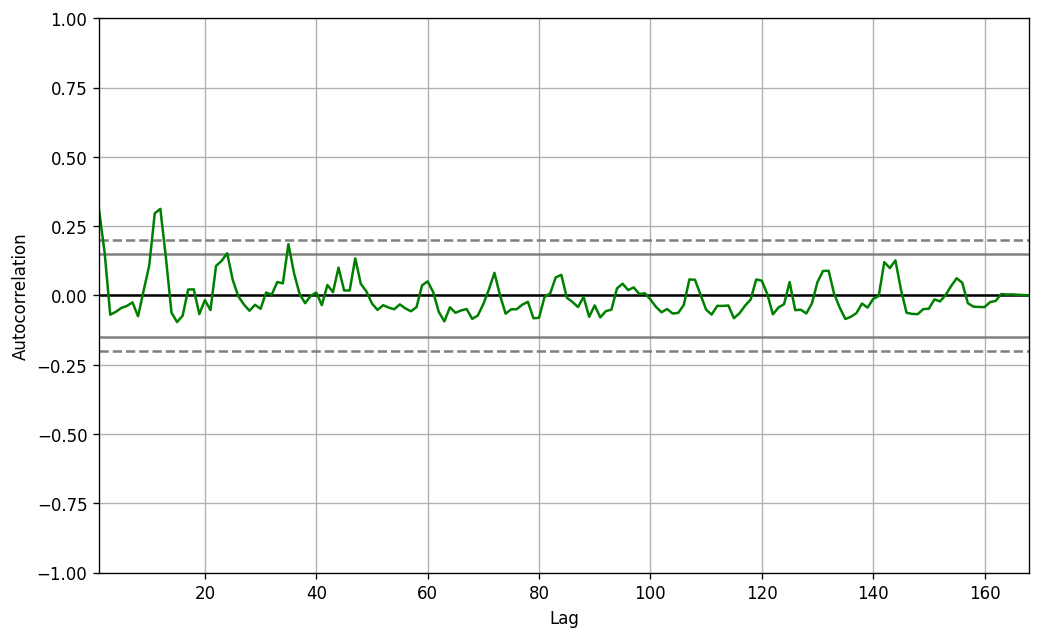

In [ ]:
# Test for seasonality
from pandas.plotting import autocorrelation_plot

# Draw Plot
plt.rcParams.update({'figure.figsize':(10,6), 'figure.dpi':120})
autocorrelation_plot(monthly_precip.tolist(),color='g')

### Autocorrelation and Partial Autocorrelation Functions

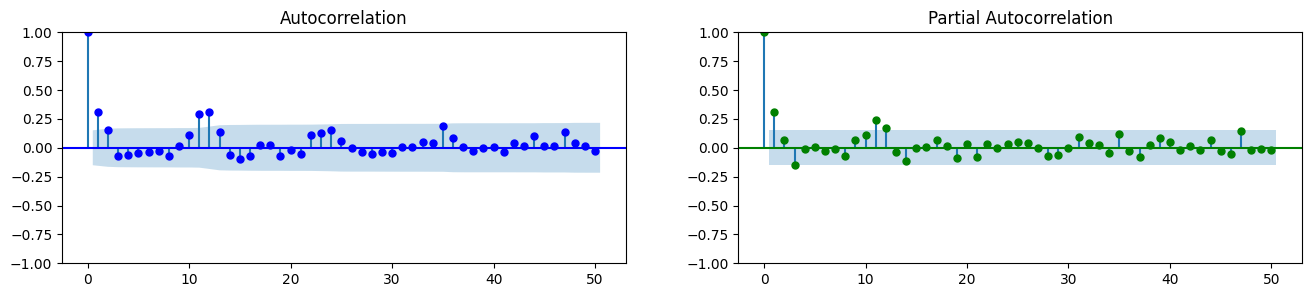

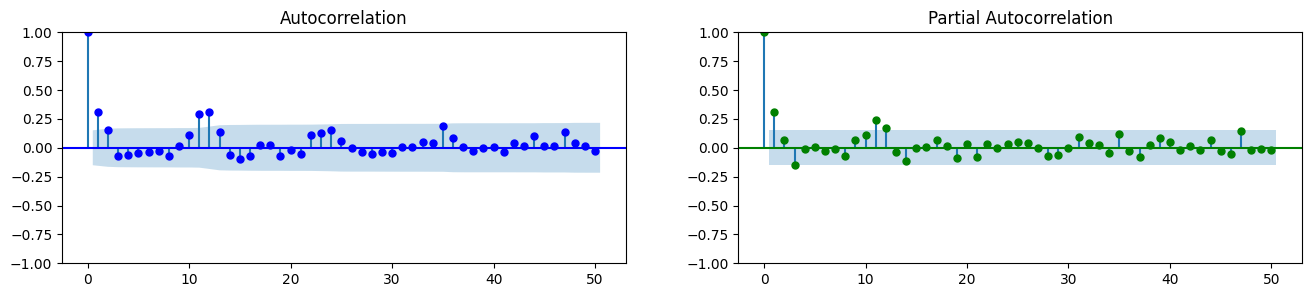

In [ ]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(monthly_precip.tolist(), lags=50, ax=axes[0],color='blue')
plot_pacf(monthly_precip.tolist(), lags=50, ax=axes[1],color='green')

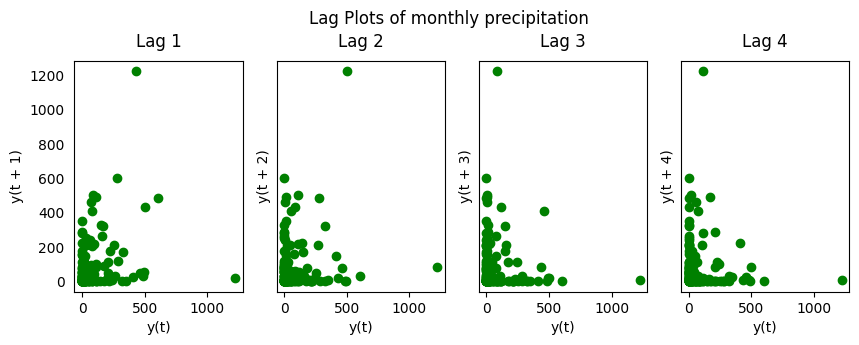

In [ ]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(monthly_precip, lag=i+1, ax=ax, c='green')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of monthly precipitation', y=1.05)
plt.show()

- The ACF shows clear spikes at lags 12, 24 indicating a strong yearly seasonality.
- The PACF shows significant spikes at lags 1 and 12, meaning:
-Lag 1: Some short-term (month-to-month) dependence.
-Lag 12: Strong seasonal dependence — confirms annual cycle again.

#TASK 2: Change‑Point Detection

##2.1 CUSUM Method

Use a Python library (e.g. ruptures or your own CUSUM code) to identify any abrupt shifts in mean precipitation for the chosen grid cell.

Plot the time series with vertical lines at detected change‑points.

In [ ]:
# install ruptures library
! pip install ruptures

Group locations by lat-lon and collect observation values to NumPy array

In [ ]:
merged_df['precip_array'] = merged_df[date_cols].values.tolist()

# Drop the original date columns
merged_df = merged_df.drop(columns=date_cols)

/tmp/ipython-input-16-1279437914.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df['precip_array'] = merged_df[date_cols].values.tolist()


In [ ]:
merged_df

,lat,lon,precip_array
0,29.0,72.500,"[0.0005329124548560001, 24.059566836, 0.001189..."
1,29.0,73.125,"[2.19070084761, 16.1915826123, 0.0003509904646..."
2,29.0,73.750,"[24.382769256, 7.29145606248, 0.00036924561585..."
3,29.0,74.375,"[12.479475799260001, 2.57211507402, 0.00027126..."
4,29.0,75.000,"[0.327676735422, 3.6466042806, 8.11195655526e-..."
...,...,...,...
250,37.0,78.750,"[6.2242109029799995, 27.9631788408, 110.435563..."
251,37.0,79.375,"[4.3464611205, 19.5226477101, 108.0764856108, ..."
252,37.0,80.000,"[0.791274052692, 5.63128988346, 75.2638319694,..."
253,37.0,80.625,"[0.1500654029544, 4.13460101376, 72.955635471,..."


In [ ]:
# build the mask
mask = (merged_df["lat"] == 29.0) & (merged_df["lon"] == 79.375)

# select the list of T2m values
prec_list = merged_df.loc[mask, "precip_array"].iloc[0]

len(prec_list)

168

In [ ]:
#!pip install indsl
from indsl.detect.cusum import Cusum

/usr/local/lib/python3.11/dist-packages/indsl/equipment/volume_vessel.py:32: IndslUserWarning: Couldn't import fluids.numba_vectorized: No module named 'fluids'. Default to import fluids.vectorized.
  warnings.warn(


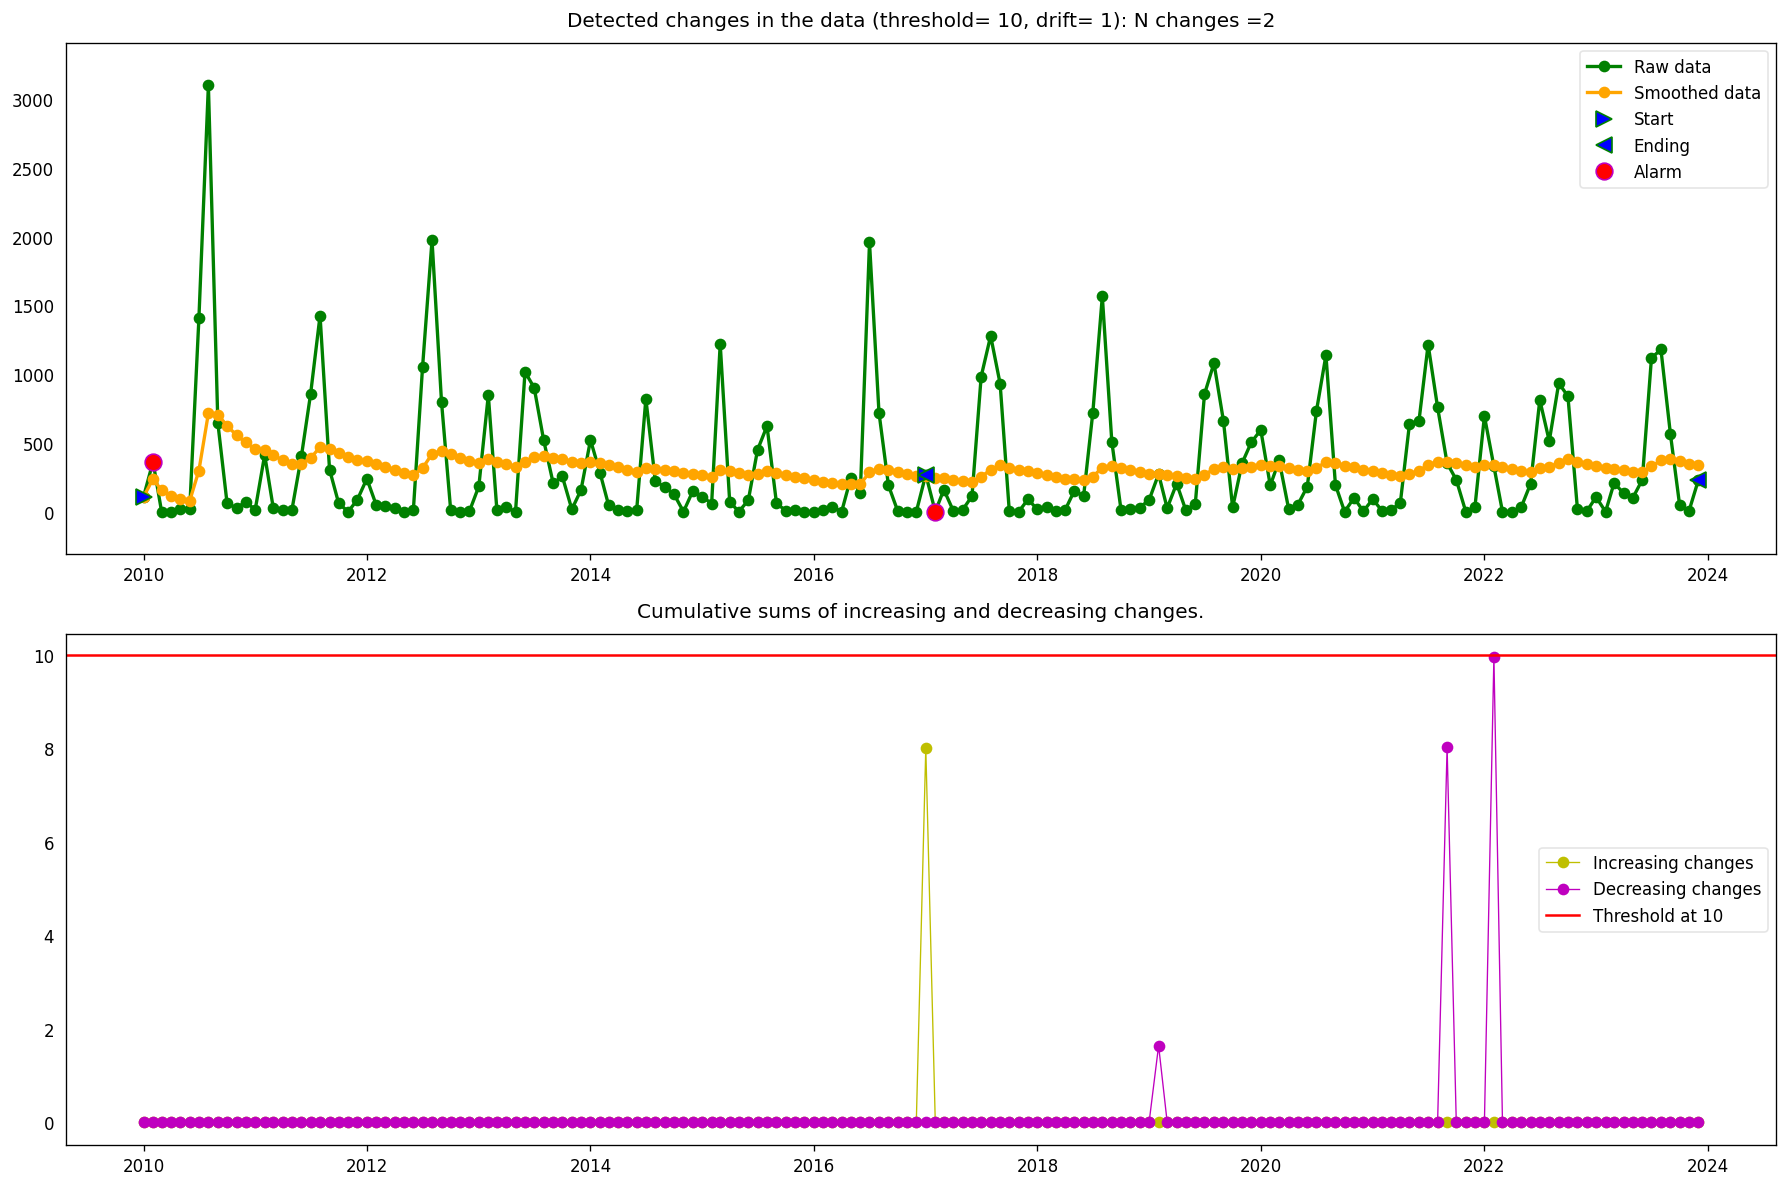

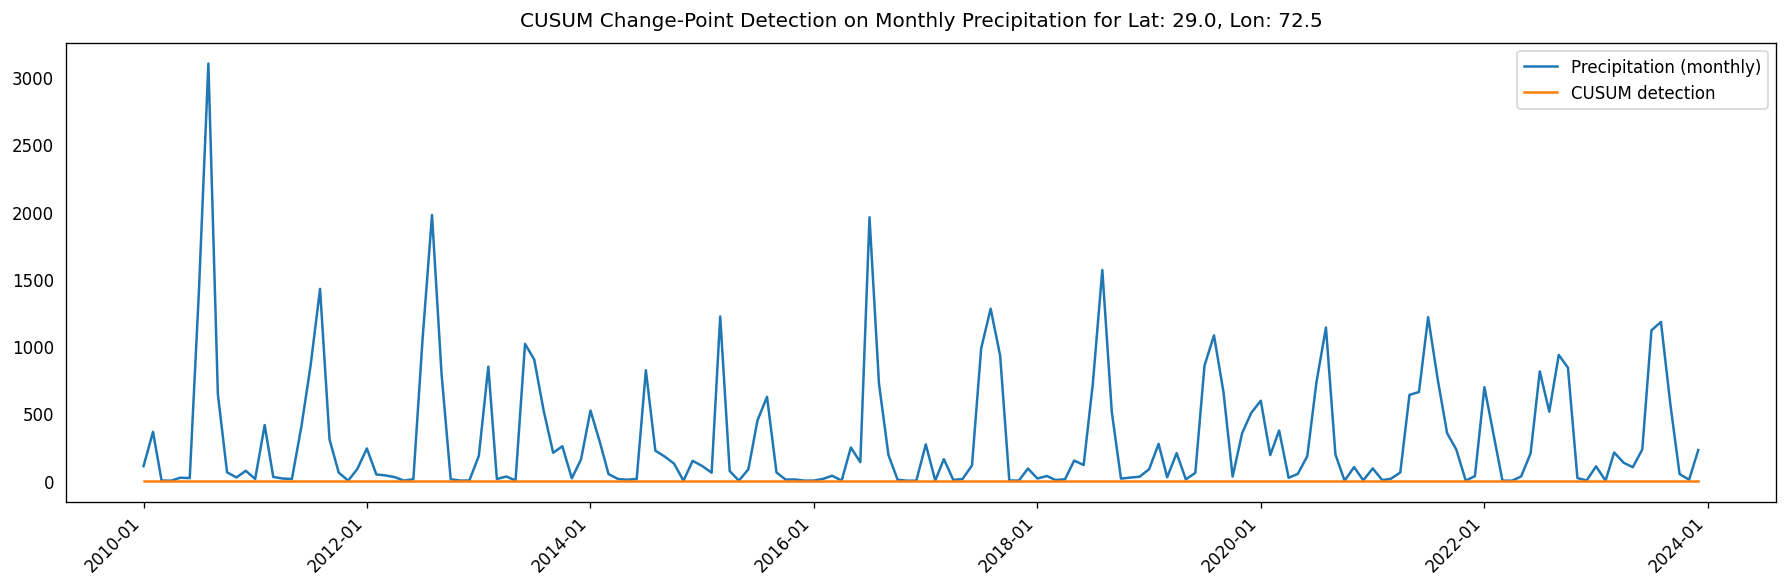


Detected Change Points:


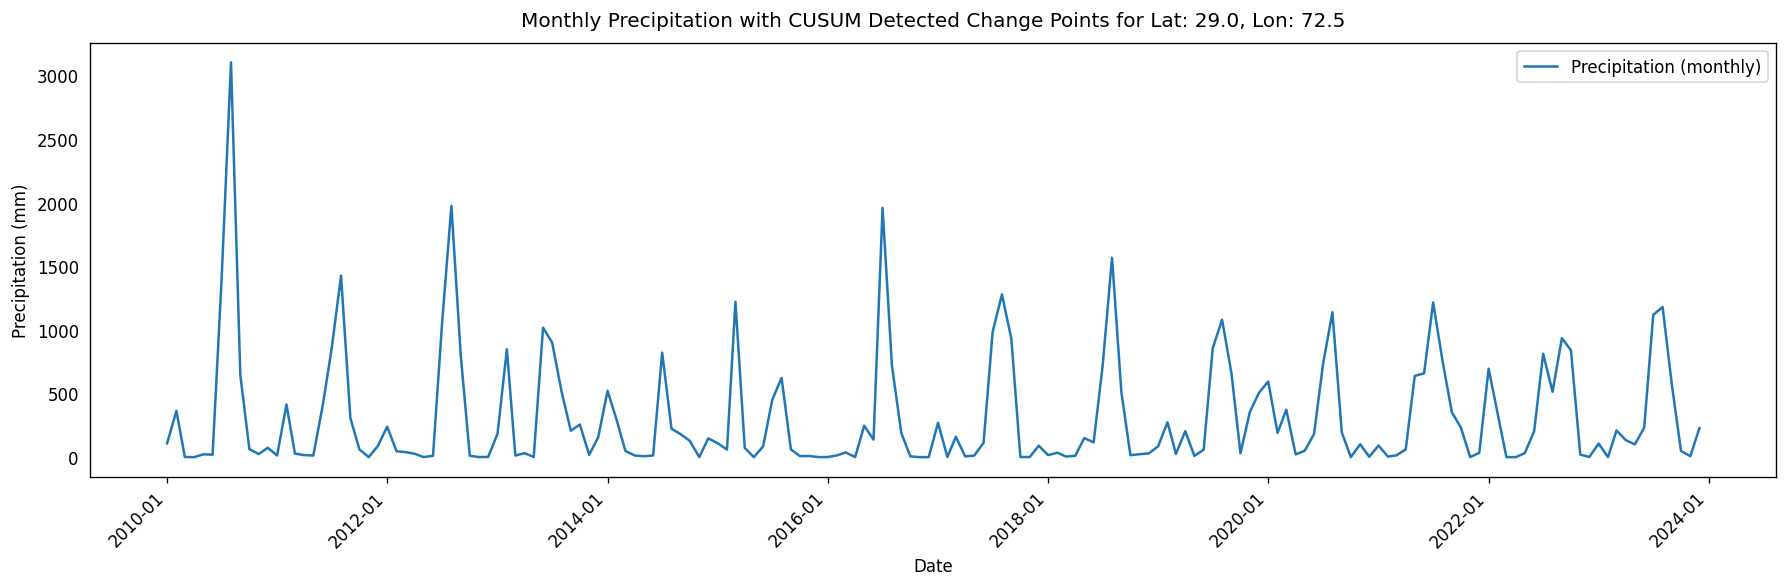

In [ ]:
# Convert the index (dates) to datetime objects
date_index = pd.to_datetime(date_cols, format='%Y-%m')

# Create a pandas Series for the CUSUM analysis
# We are using the 'prec_list' which contains the precipitation values for the chosen grid cell
prec_series = pd.Series(prec_list, index=date_index)
prec_series = prec_series.sort_index()

# Initialize the Cusum object
# Adjust threshold and drift parameters based on the characteristics of your data
cusum_obj = Cusum(
    prec_series,
    threshold=10,         # sensitivity threshold - adjust this value
    drift=1,           # drift parameter - adjust this value
    detect="both",       # detect upward and downward shifts
    predict_ending=True  # flag to extend final segment
)

# Run the CUSUM detection
res_binary = cusum_obj.cusum(plot_cusum=True) # plot_cusum=True will show the CUSUM chart

# Plot the time series with the binary detection result
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(prec_series.index, prec_series.values, label="Precipitation (monthly)")
ax.plot(res_binary.index, res_binary.values, label="CUSUM detection", drawstyle="steps-post")
ax.set_title(f"CUSUM Change-Point Detection on Monthly Precipitation for Lat: {lat_cell}, Lon: {lon_cell}")
ax.legend(loc="best")

# Format the x-axis to show Year-Month
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Find the change points from the binary detection result
change_points_indices = res_binary[res_binary.diff().fillna(0).abs() > 0].index
change_points_dates = change_points_indices.tolist()

print("\nDetected Change Points:")
for cp_date in change_points_dates:
    print(cp_date.strftime('%Y-%m'))

# Plot the time series with vertical lines at detected change points
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(prec_series.index, prec_series.values, label="Precipitation (monthly)")

# Add vertical lines for each detected change point
for cp_date in change_points_dates:
    ax.axvline(x=cp_date, color='red', linestyle='--', linewidth=1.5, label=f'Change Point: {cp_date.strftime("%Y-%m")}')

ax.set_title(f"Monthly Precipitation with CUSUM Detected Change Points for Lat: {lat_cell}, Lon: {lon_cell}")
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation (mm)")
ax.legend(loc="best")

# Format the x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 2.2 PELT Algorithm

Apply the PELT method (ruptures.Pelt) on the same series.


<Figure size 1800x600 with 0 Axes>

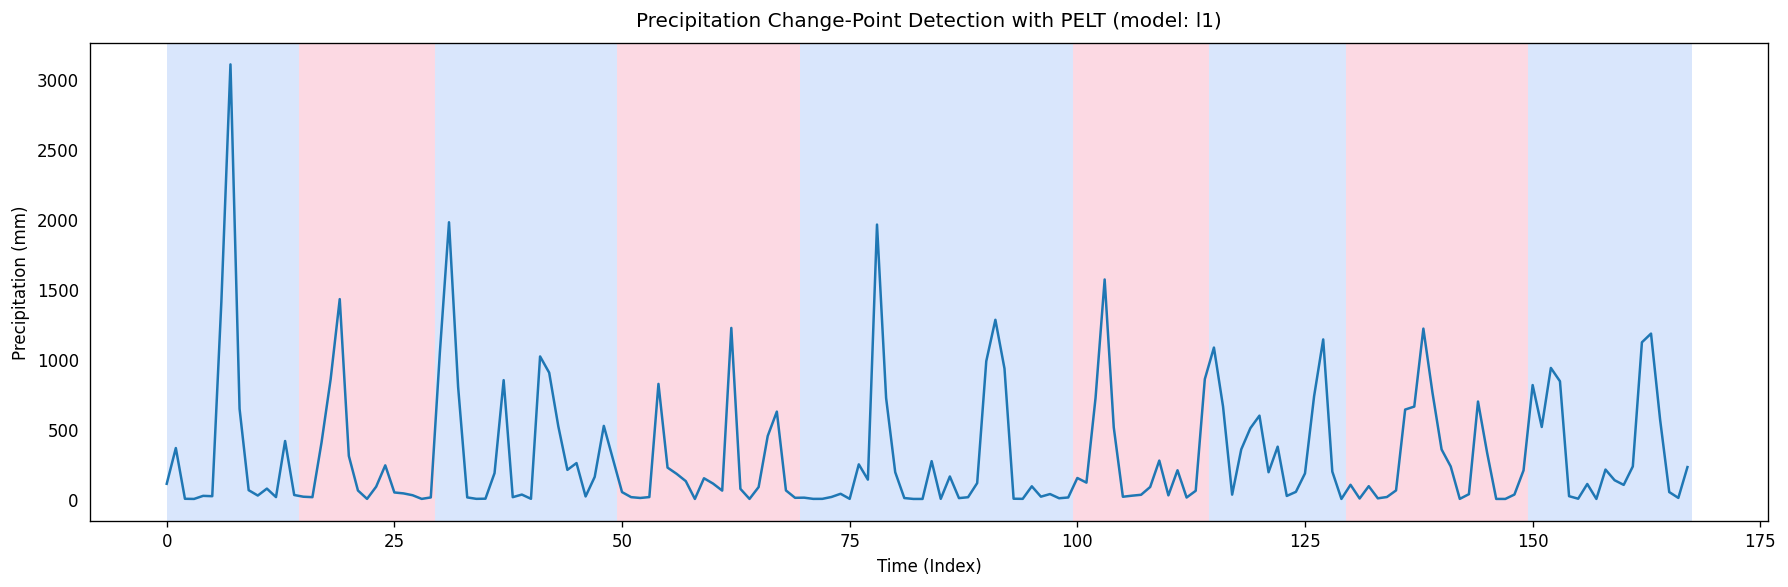

In [ ]:
import ruptures as rpt
import numpy as np

points = np.array(prec_list).reshape(-1, 1)  # must be 2D

# Choose model: 'l1', 'l2', 'rbf', etc.
model = 'l1'
algo = rpt.Pelt(model=model, min_size=12).fit(points)  # min_size=12 ensures seasonal resolution
changepoints = algo.predict(pen=5)  # adjust pen for sensitivity

# Plot with time on x-axis
plt.figure(figsize=(15, 5))
rpt.display(points, changepoints, figsize=(15, 5))
plt.title('Precipitation Change-Point Detection with PELT (model: l1)')
plt.xlabel('Time (Index)')
plt.ylabel('Precipitation (mm)')
plt.tight_layout()
plt.show()

#TASK 3: Trend Analysis (Apply on whole grid)

## 3.2 Mann–Kendall Test

For each grid cell, compute the Mann–Kendall trend test on its precipitation series (1980–2023).

In [ ]:
# install the pymannkendall library for trend analysis
! pip install pymannkendall

In [ ]:
# Trend analysis
import pymannkendall as mk

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import collections
import matplotlib.patches as mpatches
import calendar

In [ ]:
display(merged_df.iloc[0])

# Display cell content in the grouped column
display(merged_df.iloc[0]['precip_array'])
print(len(merged_df.iloc[0]['precip_array']))

,0
lat,29.0
lon,72.5
precip_array,"[0.0005329124548560001, 24.059566836, 0.001189..."


[0.0005329124548560001,
 24.059566836,
 0.0011896649793,
 1.20812933106,
 0.0254933969112,
 32.2391468574,
 252.763148106,
 210.426523866,
 48.211097777999996,
 0.088283727198,
 1.42087804722,
 80.42020443,
 1.39749715287,
 24.611075343,
 3.5438640431399997,
 14.477545243260002,
 0.200731897656,
 150.6506097186,
 325.586912256,
 169.92371176199998,
 322.495950528,
 3.78976217724,
 1.859613524568,
 0.000222119009136,
 29.2429591767,
 0.41662119987,
 3.83417292474,
 6.84218576412,
 2.50506437832,
 0.468550440378,
 178.10699191199998,
 88.39637468100001,
 79.7666123466,
 0.000100502829918,
 0.00361606651704,
 12.43423508688,
 0.00865646295678,
 349.79111809200003,
 2.19566630448,
 5.869144511280001,
 0.000332229287394,
 23.3358511356,
 83.0062866348,
 203.80973668200002,
 24.4114827273,
 7.087568983380001,
 1.296807607152,
 4.83145909272e-11,
 4.40699464584,
 2.5818937223400003,
 33.4778825898,
 40.1861526264,
 10.168095402,
 10.297517064300001,
 87.5783254248,
 28.0503856386,
 57.0891658

168


In [ ]:
# Check the ouput of the MK test function
array = merged_df.iloc[0]['precip_array']
#original MK test
result = mk.original_test(array, alpha=0.05)
display(result)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.06626135576507175), z=np.float64(1.8366515244974777), Tau=np.float64(0.09552323923581409), s=np.float64(1340.0), var_s=531505.3333333334, slope=np.float64(0.020658960185176774), intercept=np.float64(12.12831313426774))

In [ ]:
%%time
# Apply MK test rowwise and collect result into new column
merged_df['result'] = merged_df['precip_array'].apply(lambda x: mk.original_test(x, alpha=0.05))

merged_df['trend'] = merged_df['result'].apply(lambda x: x[0])
merged_df['h'] = merged_df['result'].apply(lambda x: x[1])
merged_df['p'] = merged_df['result'].apply(lambda x: x[2])
merged_df['z'] = merged_df['result'].apply(lambda x: x[3])
merged_df['Tau'] = merged_df['result'].apply(lambda x: x[4])
merged_df['s'] = merged_df['result'].apply(lambda x: x[5])
merged_df['var_s'] = merged_df['result'].apply(lambda x: x[6])
merged_df['slope'] = merged_df['result'].apply(lambda x: x[7]*12)
merged_df['intercept'] = merged_df['result'].apply(lambda x: x[8])

display(merged_df)

,lat,lon,precip_array,result,trend,h,p,z,Tau,s,var_s,slope,intercept
0,29.0,72.500,"[0.0005329124548560001, 24.059566836, 0.001189...","(no trend, False, 0.06626135576507175, 1.83665...",no trend,False,0.066261,1.836652,0.095523,1340.0,531505.333333,0.247908,12.128313
1,29.0,73.125,"[2.19070084761, 16.1915826123, 0.0003509904646...","(increasing, True, 0.04057107053505149, 2.0478...",increasing,True,0.040571,2.047887,0.106501,1494.0,531505.333333,0.399694,13.360193
2,29.0,73.750,"[24.382769256, 7.29145606248, 0.00036924561585...","(no trend, False, 0.05639408598993567, 1.90797...",no trend,False,0.056394,1.907978,0.099230,1392.0,531505.333333,0.346570,16.518567
3,29.0,74.375,"[12.479475799260001, 2.57211507402, 0.00027126...","(no trend, False, 0.061925607605118005, 1.8668...",no trend,False,0.061926,1.866828,0.097092,1362.0,531505.333333,0.313161,18.998892
4,29.0,75.000,"[0.327676735422, 3.6466042806, 8.11195655526e-...","(no trend, False, 0.13886786649739968, 1.48002...",no trend,False,0.138868,1.480020,0.076989,1080.0,531505.333333,0.230881,29.766966
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,37.0,78.750,"[6.2242109029799995, 27.9631788408, 110.435563...","(increasing, True, 0.039771242001194196, 2.056...",increasing,True,0.039771,2.056117,0.106929,1500.0,531505.333333,2.562872,43.833804
251,37.0,79.375,"[4.3464611205, 19.5226477101, 108.0764856108, ...","(increasing, True, 0.004164882585496521, 2.865...",increasing,True,0.004165,2.865396,0.148988,2090.0,531505.333333,2.264570,19.551779
252,37.0,80.000,"[0.791274052692, 5.63128988346, 75.2638319694,...","(increasing, True, 0.002112887202103897, 3.073...",increasing,True,0.002113,3.073888,0.159823,2242.0,531505.333333,1.018620,7.637030
253,37.0,80.625,"[0.1500654029544, 4.13460101376, 72.955635471,...","(increasing, True, 0.002074356332950833, 3.079...",increasing,True,0.002074,3.079375,0.160108,2246.0,531505.333333,0.544991,4.540053


CPU times: user 2.02 s, sys: 46.5 ms, total: 2.06 s
Wall time: 2.37 s


In [ ]:
display(merged_df['trend'].value_counts())

,count
trend,
no trend,211
increasing,44


Successfully loaded India shapefile from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module2/Shape%20File/NWH_States_Shapefile/NWH_states.shp

Generating Plot Style (a) - Scatter Bg, Directional Marker Color...
Generated Z-statistic scatter background.
Generating Plot Style (b) - Scatter Bg, Directional Marker Color...
Generated Sen's slope scatter background.


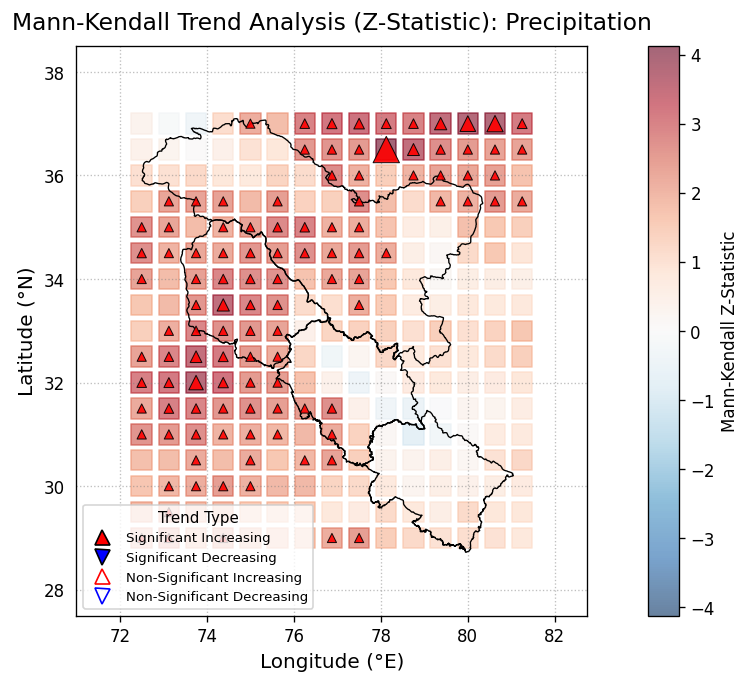

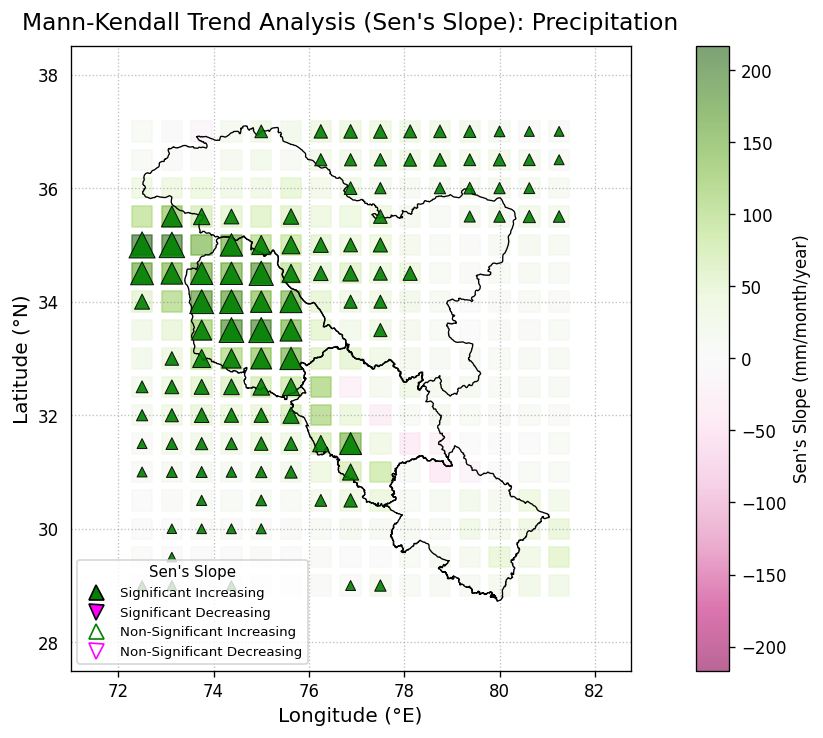


Finished generating plots.


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable # For colorbar placement
import matplotlib.colors as mcolors # For color normalization
import matplotlib.cm as cm # For colormaps and ScalarMappable
import os
# NOTE: Removed scipy.interpolate import as it's no longer needed

# --- Load India Shapefile ---
shapefile_path = 'https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module2/Shape%20File/NWH_States_Shapefile/NWH_states.shp' # load path of shape file
india_shape = gpd.read_file(shapefile_path)
shapefile_loaded = True
india_shape = india_shape.to_crs(epsg=4326)
print(f"Successfully loaded India shapefile from {shapefile_path}")

# Define the variable being plotted
var = "Precipitation"
var_label = "Precipitation"

# --- 1. Load your data ---
try:
    df = merged_df.copy()
    df.reset_index(inplace=True)

except NameError:
    print("merged_df not found, using dummy data.")

# --- Data Preprocessing ---
required_cols = ['lat', 'lon', 'z', 'slope', 'p', 'h', 'trend']
try:
    for col in required_cols:
        if col not in df.columns: raise KeyError(f"Required column '{col}' not found.")
        if col in ['lat', 'lon', 'z', 'slope', 'p']: df[col] = pd.to_numeric(df[col])
        elif col == 'h':
             if df[col].dtype != bool:
                 if df[col].isin([0, 1]).all(): df[col] = df[col].astype(bool)
                 elif df[col].astype(str).str.lower().isin(['true', 'false']).all(): df[col] = df[col].astype(str).str.lower().map({'true': True, 'false': False})
                 else:
                      print(f"Warning: Col 'h' not bool. Assuming signif based on 'p'<0.05.")
                      df['p'] = pd.to_numeric(df['p'], errors='coerce')
                      df['h'] = df['p'] < 0.05
             df[col] = df[col].astype(bool)
except KeyError as e: print(f"Error: {e}"); exit()
except Exception as e: print(f"Error during data conversion: {e}"); exit()

try:
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")
except Exception as e: print(f"Error creating GeoDataFrame: {e}"); exit()

cols_to_check = ['lon', 'lat', 'z', 'slope', 'p']
initial_rows = len(gdf)
gdf.dropna(subset=cols_to_check, inplace=True)
if len(gdf) < initial_rows: print(f"Warning: Dropped {initial_rows - len(gdf)} rows with NaNs.")
if gdf.empty: print("Error: DataFrame empty after NaN drop."); exit()

try:
    conditions = [ (gdf['h']==True)&(gdf['trend']=='increasing'), (gdf['h']==True)&(gdf['trend']=='decreasing'), (gdf['h']==False)&(gdf['trend']=='increasing'), (gdf['h']==False)&(gdf['trend']=='decreasing') ]
    choices = ['Sig Inc', 'Sig Dec', 'Non-Sig Inc', 'Non-Sig Dec']
    gdf['category'] = np.select(conditions, choices, default='No Trend')
except KeyError as e: print(f"Error categorizing: {e}"); exit()

# --- Plotting Setup ---
xmin, ymin, xmax, ymax = gdf.total_bounds
buffer = 1.5
plot_lon_min, plot_lon_max = xmin - buffer, xmax + buffer
plot_lat_min, plot_lat_max = ymin - buffer, ymax + buffer

# Colormaps for background scatter
cmap_z_name = 'RdBu_r'; cmap_z = plt.get_cmap(cmap_z_name)
cmap_slope_name = 'PiYG'; cmap_slope = plt.get_cmap(cmap_slope_name)

# Normalization for background scatter
z_max_abs = gdf['z'].abs().max(); z_max_abs = max(z_max_abs, 1.0)
norm_z = mcolors.Normalize(vmin=-z_max_abs, vmax=z_max_abs)
slope_max_abs = gdf['slope'].abs().max(); slope_max_abs = max(slope_max_abs, 1e-9)
norm_slope = mcolors.Normalize(vmin=-slope_max_abs, vmax=slope_max_abs)

# Marker Sizes (for triangles)
min_marker_size = 30; max_marker_size = 250; epsilon = 1e-9
if 'p' in gdf.columns and not gdf['p'].isna().all():
    inv_p = 1.0 / (gdf['p'] + epsilon); min_inv_p=inv_p.min(); max_inv_p=inv_p.max()
    norm_inv_p = (inv_p-min_inv_p)/(max_inv_p-min_inv_p) if max_inv_p>min_inv_p else 0.5
    gdf['marker_size_p'] = min_marker_size + norm_inv_p * (max_marker_size - min_marker_size)
else: gdf['marker_size_p'] = (min_marker_size + max_marker_size) / 2

if 'slope' in gdf.columns and not gdf['slope'].isna().all():
    abs_slope = gdf['slope'].abs(); min_abs_slope=abs_slope.min(); max_abs_slope=abs_slope.max()
    norm_abs_slope = (abs_slope-min_abs_slope)/(max_abs_slope-min_abs_slope) if max_abs_slope>min_abs_slope else 0.5
    gdf['marker_size_slope'] = min_marker_size + norm_abs_slope * (max_abs_slope - min_abs_slope)
else: gdf['marker_size_slope'] = (min_marker_size + max_marker_size) / 2

# --- Subsets for plotting ---
sig_inc = gdf[gdf['category'] == 'Sig Inc']
sig_dec = gdf[gdf['category'] == 'Sig Dec']
nonsig_inc = gdf[gdf['category'] == 'Non-Sig Inc']
nonsig_dec = gdf[gdf['category'] == 'Non-Sig Dec']

# --- Define Fixed Marker Colors (for triangles) ---
color_inc_z = 'red'    # For Z plot, increasing trend
color_dec_z = 'blue'   # For Z plot, decreasing trend
color_inc_s = 'green'  # For Slope plot, increasing trend
color_dec_s = 'magenta'# For Slope plot, decreasing trend
marker_edge_color = 'black' # Edge color for significant markers

# --- Legend Elements (Plot-Specific Colors for triangles) ---
legend_elements_z = [
    Line2D([0],[0], marker='^', color='none', label='Significant Increasing', markerfacecolor=color_inc_z, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Significant Decreasing', markerfacecolor=color_dec_z, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='^', color='none', label='Non-Significant Increasing', markerfacecolor='none', markeredgecolor=color_inc_z, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Non-Significant Decreasing', markerfacecolor='none', markeredgecolor=color_dec_z, markersize=9)
]
legend_elements_s = [
    Line2D([0],[0], marker='^', color='none', label='Significant Increasing', markerfacecolor=color_inc_s, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Significant Decreasing', markerfacecolor=color_dec_s, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='^', color='none', label='Non-Significant Increasing', markerfacecolor='none', markeredgecolor=color_inc_s, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Non-Significant Decreasing', markerfacecolor='none', markeredgecolor=color_dec_s, markersize=9)
]

# --- Scatter Background Parameters ---
base_marker_size = 150 # Size of the background points
base_alpha = 0.6       # Transparency of background points


# ===================================================================================
# Plot 1: Scatter Z Background, Directional Color Markers (Sized by P-val)
# ===================================================================================
print("\nGenerating Plot Style (a) - Scatter Bg, Directional Marker Color...")
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 7))
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
ax1.set_facecolor('white') # White background behind scatter if needed

# --- Plot Scatter Background (Z-Statistic) ---
try:
    sc_base_z = ax1.scatter(gdf['lon'], gdf['lat'], marker='s', # Squares for background
                           s=base_marker_size,      # Fixed large size
                           c=gdf['z'],              # Color by Z value
                           cmap=cmap_z, norm=norm_z,# Use Z colormap/norm
                           alpha=base_alpha,        # Apply transparency
                           zorder=0, label='_nolegend_') # Bottom layer
    print("Generated Z-statistic scatter background.")
    # Colorbar represents the background scatter
    fig1.colorbar(sc_base_z, cax=cax1, label='Mann-Kendall Z-Statistic')
except Exception as e:
    print(f"Warning: Could not generate Z scatter background: {e}")
    ax1.set_facecolor('lightgray') # Fallback background
    # Fallback colorbar
    sm_z = cm.ScalarMappable(cmap=cmap_z, norm=norm_z); sm_z.set_array(gdf['z'])
    fig1.colorbar(sm_z, cax=cax1, label='Z-Statistic (Background Failed)')

# --- Plot Grid ---
ax1.grid(True, linestyle=':', color='gray', alpha=0.5, zorder=1) # Grid above background scatter

# --- Plot India Boundary ---
india_shape.boundary.plot(ax=ax1, color='black', linewidth=0.8, zorder=2) # Boundary above grid
#except Exception as e: print(f"Warning: Could not plot India boundary on Plot 1: {e}")

# --- Plot Specific Trend Markers (Triangles - Directional Color) ---
marker_alpha = 0.9 # Alpha for main markers
# Non-Significant (zorder=3)
if not nonsig_inc.empty:
    ax1.scatter(nonsig_inc.geometry.x, nonsig_inc.geometry.y, marker='^', s=nonsig_inc['marker_size_p'], facecolor='none', edgecolor=color_inc_z, linewidth=1.0, zorder=3, alpha=marker_alpha)
if not nonsig_dec.empty:
    ax1.scatter(nonsig_dec.geometry.x, nonsig_dec.geometry.y, marker='v', s=nonsig_dec['marker_size_p'], facecolor='none', edgecolor=color_dec_z, linewidth=1.0, zorder=3, alpha=marker_alpha)
# Significant (zorder=4)
if not sig_inc.empty:
    ax1.scatter(sig_inc.geometry.x, sig_inc.geometry.y, marker='^', s=sig_inc['marker_size_p'], c=color_inc_z, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)
if not sig_dec.empty:
    ax1.scatter(sig_dec.geometry.x, sig_dec.geometry.y, marker='v', s=sig_dec['marker_size_p'], c=color_dec_z, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)

# --- Add Legend (for triangles) ---
ax1.legend(handles=legend_elements_z, loc='lower left', title="Trend Type", fontsize=8, title_fontsize=9, framealpha=0.8)

# --- Add Titles and Labels ---
ax1.set_title(f'Mann-Kendall Trend Analysis (Z-Statistic): {var_label}', fontsize=14, pad=10)
ax1.set_xlabel('Longitude (°E)', fontsize=12)
ax1.set_ylabel('Latitude (°N)', fontsize=12)
ax1.set_xlim(plot_lon_min, plot_lon_max)
ax1.set_ylim(plot_lat_min, plot_lat_max)

# ===================================================================================
# Plot 2: Scatter Slope Background, Directional Color Markers (Sized by Slope)
# ===================================================================================
print("Generating Plot Style (b) - Scatter Bg, Directional Marker Color...")
fig2, ax2 = plt.subplots(1, 1, figsize=(7, 7))
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.1)
ax2.set_facecolor('white')

# --- Plot Scatter Background (Sen's Slope) ---
try:
    sc_base_s = ax2.scatter(gdf['lon'], gdf['lat'], marker='s', # Squares for background
                           s=base_marker_size,      # Fixed large size
                           c=gdf['slope'],            # Color by Slope value
                           cmap=cmap_slope, norm=norm_slope,# Use Slope colormap/norm
                           alpha=base_alpha,        # Apply transparency
                           zorder=0, label='_nolegend_') # Bottom layer
    print("Generated Sen's slope scatter background.")
    # Colorbar represents the background scatter
    # Determine units based on the likely content of 'precip_array'
    # If 'precip_array' comes from the precipitation data (mm/month),
    # the slope units should be mm/month/year or mm/year
    if ('precip_array' in df.columns): # Check if the column exists
         # Assuming 'precip_array' stores precipitation in mm/month
         units = "mm/month"
    else: units = "Unknown" # Fallback if column doesn't exist or units are uncertain

    # The slope from pymannkendall is per time step. Since our data is monthly,
    # the time step is 1 month. So slope units are original_units/month.
    # If we want units per year, we multiply by 12.
    # The code already multiplies by 12, so the units are original_units/year.
    if units != "Unknown":
        slope_units = f"{units}/year"
    else:
         # If units are unknown, still indicate it's per year after multiplying by 12
         slope_units = "Unitless/year" if units != "Unitless" else "year⁻¹" # Refined fallback

    fig2.colorbar(sc_base_s, cax=cax2, label=f"Sen's Slope ({slope_units})")
except Exception as e:
    print(f"Warning: Could not generate Slope scatter background: {e}")
    ax2.set_facecolor('lightgray') # Fallback background
    # Fallback colorbar
    sm_slope = cm.ScalarMappable(cmap=cmap_slope, norm=norm_slope); sm_slope.set_array(gdf['slope'])
    # Use the same logic for fallback colorbar label
    if ('precip_array' in df.columns):
        units = "mm/month"
    else: units = "Unknown"
    if units != "Unknown":
        slope_units = f"{units}/year"
    else:
         slope_units = "Unitless/year" if units != "Unitless" else "year⁻¹"
    fig2.colorbar(sm_slope, cax=cax2, label=f"Sen's Slope ({slope_units}) (Background Failed)")


# --- Plot Grid ---
ax2.grid(True, linestyle=':', color='gray', alpha=0.5, zorder=1) # Grid above background scatter

# --- Plot India Boundary ---
india_shape.boundary.plot(ax=ax2, color='black', linewidth=0.8, zorder=2) # Boundary above grid

# --- Plot Specific Trend Markers (Triangles - Directional Color) ---
# Non-Significant (zorder=3)
if not nonsig_inc.empty:
    ax2.scatter(nonsig_inc.geometry.x, nonsig_inc.geometry.y, marker='^', s=nonsig_inc['marker_size_slope'], facecolor='none', edgecolor=color_inc_s, linewidth=1.0, zorder=3, alpha=marker_alpha)
if not nonsig_dec.empty:
    ax2.scatter(nonsig_dec.geometry.x, nonsig_dec.geometry.y, marker='v', s=nonsig_dec['marker_size_slope'], facecolor='none', edgecolor=color_dec_s, linewidth=1.0, zorder=3, alpha=marker_alpha)
# Significant (zorder=4)
if not sig_inc.empty:
    ax2.scatter(sig_inc.geometry.x, sig_inc.geometry.y, marker='^', s=sig_inc['marker_size_slope'], c=color_inc_s, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)
if not sig_dec.empty:
    ax2.scatter(sig_dec.geometry.x, sig_dec.geometry.y, marker='v', s=sig_dec['marker_size_slope'], c=color_dec_s, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)

# --- Add Legend (for triangles) ---
ax2.legend(handles=legend_elements_s, loc='lower left', title="Sen's Slope", fontsize=8, title_fontsize=9, framealpha=0.8)

# --- Add Titles and Labels ---
ax2.set_title(f"Mann-Kendall Trend Analysis (Sen's Slope): {var_label}", fontsize=14, pad=10)
ax2.set_xlabel('Longitude (°E)', fontsize=12)
ax2.set_ylabel('Latitude (°N)', fontsize=12)
ax2.set_xlim(plot_lon_min, plot_lon_max)
ax2.set_ylim(plot_lat_min, plot_lat_max)

# --- Display and Save Plots ---
plt.tight_layout()

# --- Save Figures ---
# save_dir = f'/content/drive/MyDrive/Research Result/NWH_Trend Plots(Cloud_Data)(SMK-Test)/{var} Trend Plots_ScatterBg_DirMarkerColor' # Updated dir name
# os.makedirs(save_dir, exist_ok=True)
# print(f"\nAttempting to save figures to: {save_dir}")
# try:
#     fig1_path = os.path.join(save_dir, f'{var}_MK_Trend_Z_ScatterBg_DirColorPvalSize.png')
#     fig2_path = os.path.join(save_dir, f'{var}_MK_Trend_Slope_ScatterBg_DirColorSlopeSize.png')
#     fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
#     fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
#     print(f"Figures potentially saved.")
# except Exception as e:
#     print(f"Error saving figures: {e}")

plt.show()

print("\nFinished generating plots.")

##3.3 Seasonal Mann–Kendall

Apply SMK Test on the given dataset and observe the result of MK and SMK Test

Apply for one location

In [ ]:
# Check the ouput of the MK test function
array = merged_df.iloc[0]['precip_array']
# Seasonal MK Test
result = mk.seasonal_test(array,period=12, alpha=0.05)
display(result)

Seasonal_Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.04821868327371459), z=np.float64(1.9754360663781687), Tau=np.float64(0.11538461538461539), s=np.float64(126.0), var_s=4003.9999999999995, slope=np.float64(0.17017038218507574), intercept=np.float64(12.669234067025515))

In [ ]:
%%time
# Apply MK test rowwise and collect result into new column
merged_df['result'] = merged_df['precip_array'].apply(lambda x: mk.seasonal_test(x,period=12, alpha=0.05))

merged_df['trend'] = merged_df['result'].apply(lambda x: x[0])
merged_df['h'] = merged_df['result'].apply(lambda x: x[1])
merged_df['p'] = merged_df['result'].apply(lambda x: x[2])
merged_df['z'] = merged_df['result'].apply(lambda x: x[3])
merged_df['Tau'] = merged_df['result'].apply(lambda x: x[4])
merged_df['s'] = merged_df['result'].apply(lambda x: x[5])
merged_df['var_s'] = merged_df['result'].apply(lambda x: x[6])
merged_df['slope'] = merged_df['result'].apply(lambda x: x[7]*12)
merged_df['intercept'] = merged_df['result'].apply(lambda x: x[8])

display(merged_df)

,lat,lon,precip_array,result,trend,h,p,z,Tau,s,var_s,slope,intercept
0,29.0,72.500,"[0.0005329124548560001, 24.059566836, 0.001189...","(increasing, True, 0.04821868327371459, 1.9754...",increasing,True,0.048219,1.975436,0.115385,126.0,4004.0,2.042045,12.669234
1,29.0,73.125,"[2.19070084761, 16.1915826123, 0.0003509904646...","(increasing, True, 0.020173092776212487, 2.323...",increasing,True,0.020173,2.323113,0.135531,148.0,4004.0,4.058047,13.788290
2,29.0,73.750,"[24.382769256, 7.29145606248, 0.00036924561585...","(no trend, False, 0.05584771105899411, 1.91222...",no trend,False,0.055848,1.912222,0.111722,122.0,4004.0,2.414654,17.529950
3,29.0,74.375,"[12.479475799260001, 2.57211507402, 0.00027126...","(increasing, True, 0.02193417466818981, 2.2915...",increasing,True,0.021934,2.291506,0.133700,146.0,4004.0,3.284857,19.273208
4,29.0,75.000,"[0.327676735422, 3.6466042806, 8.11195655526e-...","(no trend, False, 0.0644566347210691, 1.849008...",no trend,False,0.064457,1.849008,0.108059,118.0,4004.0,2.320931,30.027699
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,37.0,78.750,"[6.2242109029799995, 27.9631788408, 110.435563...","(increasing, True, 0.002540576484469259, 3.018...",increasing,True,0.002541,3.018466,0.175824,192.0,4004.0,27.600451,45.662694
251,37.0,79.375,"[4.3464611205, 19.5226477101, 108.0764856108, ...","(increasing, True, 0.0003340021357021161, 3.58...",increasing,True,0.000334,3.587392,0.208791,228.0,4004.0,24.157519,21.301407
252,37.0,80.000,"[0.791274052692, 5.63128988346, 75.2638319694,...","(increasing, True, 0.00013973280756740536, 3.8...",increasing,True,0.000140,3.808641,0.221612,242.0,4004.0,11.566238,8.018115
253,37.0,80.625,"[0.1500654029544, 4.13460101376, 72.955635471,...","(increasing, True, 0.00012291022629629111, 3.8...",increasing,True,0.000123,3.840248,0.223443,244.0,4004.0,6.346455,4.652216


CPU times: user 1.4 s, sys: 52 ms, total: 1.45 s
Wall time: 1.44 s


In [ ]:
display(merged_df['trend'].value_counts())

,count
trend,
no trend,145
increasing,110


Successfully loaded India shapefile from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module2/Shape%20File/NWH_States_Shapefile/NWH_states.shp

Generating Plot Style (a) - Scatter Bg, Directional Marker Color...
Generated Z-statistic scatter background.
Generating Plot Style (b) - Scatter Bg, Directional Marker Color...
Generated Sen's slope scatter background.


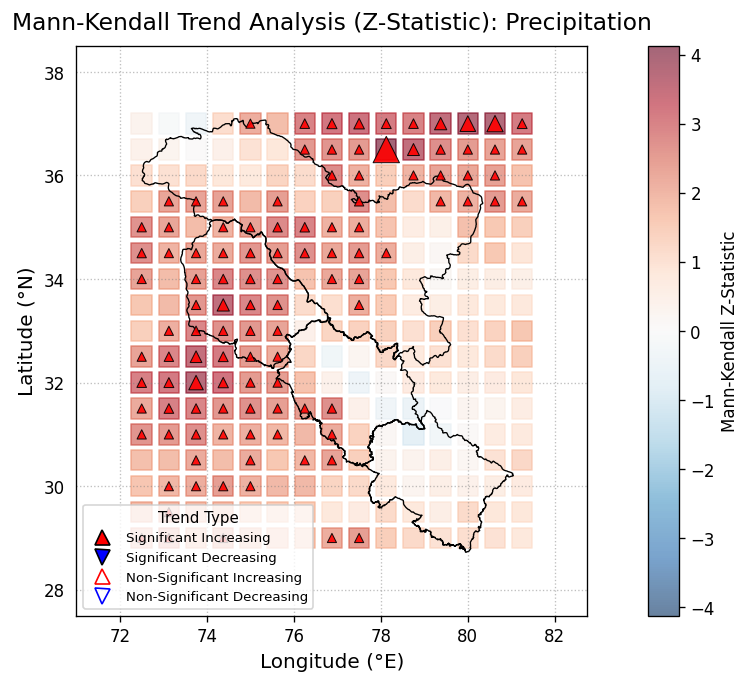

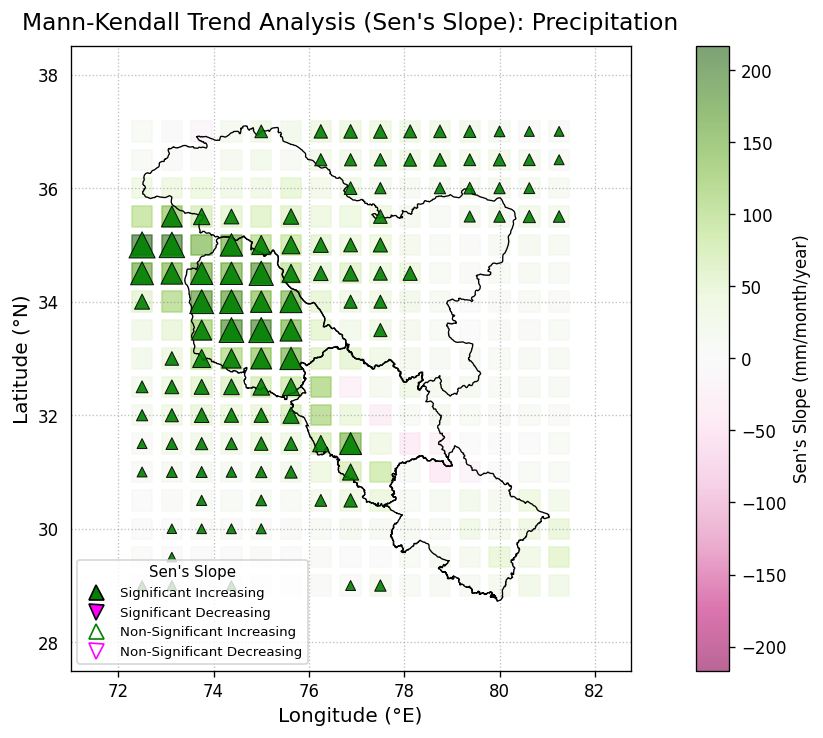


Finished generating plots.


In [ ]:
# NOTE: Removed scipy.interpolate import as it's no longer needed

# --- Load India Shapefile ---
shapefile_path = 'https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module2/Shape%20File/NWH_States_Shapefile/NWH_states.shp' # load path of shape file
india_shape = gpd.read_file(shapefile_path)
shapefile_loaded = True
india_shape = india_shape.to_crs(epsg=4326)
print(f"Successfully loaded India shapefile from {shapefile_path}")

# --- 1. Load your data ---
try:
    df = merged_df.copy()
    df.reset_index(inplace=True)

except NameError:
    print("merged_df not found, using dummy data.")

# --- Data Preprocessing ---
required_cols = ['lat', 'lon', 'z', 'slope', 'p', 'h', 'trend']
try:
    for col in required_cols:
        if col not in df.columns: raise KeyError(f"Required column '{col}' not found.")
        if col in ['lat', 'lon', 'z', 'slope', 'p']: df[col] = pd.to_numeric(df[col])
        elif col == 'h':
             if df[col].dtype != bool:
                 if df[col].isin([0, 1]).all(): df[col] = df[col].astype(bool)
                 elif df[col].astype(str).str.lower().isin(['true', 'false']).all(): df[col] = df[col].astype(str).str.lower().map({'true': True, 'false': False})
                 else:
                      print(f"Warning: Col 'h' not bool. Assuming signif based on 'p'<0.05.")
                      df['p'] = pd.to_numeric(df['p'], errors='coerce')
                      df['h'] = df['p'] < 0.05
             df[col] = df[col].astype(bool)
except KeyError as e: print(f"Error: {e}"); exit()
except Exception as e: print(f"Error during data conversion: {e}"); exit()

try:
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")
except Exception as e: print(f"Error creating GeoDataFrame: {e}"); exit()

cols_to_check = ['lon', 'lat', 'z', 'slope', 'p']
initial_rows = len(gdf)
gdf.dropna(subset=cols_to_check, inplace=True)
if len(gdf) < initial_rows: print(f"Warning: Dropped {initial_rows - len(gdf)} rows with NaNs.")
if gdf.empty: print("Error: DataFrame empty after NaN drop."); exit()

try:
    conditions = [ (gdf['h']==True)&(gdf['trend']=='increasing'), (gdf['h']==True)&(gdf['trend']=='decreasing'), (gdf['h']==False)&(gdf['trend']=='increasing'), (gdf['h']==False)&(gdf['trend']=='decreasing') ]
    choices = ['Sig Inc', 'Sig Dec', 'Non-Sig Inc', 'Non-Sig Dec']
    gdf['category'] = np.select(conditions, choices, default='No Trend')
except KeyError as e: print(f"Error categorizing: {e}"); exit()

# --- Plotting Setup ---
xmin, ymin, xmax, ymax = gdf.total_bounds
buffer = 1.5
plot_lon_min, plot_lon_max = xmin - buffer, xmax + buffer
plot_lat_min, plot_lat_max = ymin - buffer, ymax + buffer

# Colormaps for background scatter
cmap_z_name = 'RdBu_r'; cmap_z = plt.get_cmap(cmap_z_name)
cmap_slope_name = 'PiYG'; cmap_slope = plt.get_cmap(cmap_slope_name)

# Normalization for background scatter
z_max_abs = gdf['z'].abs().max(); z_max_abs = max(z_max_abs, 1.0)
norm_z = mcolors.Normalize(vmin=-z_max_abs, vmax=z_max_abs)
slope_max_abs = gdf['slope'].abs().max(); slope_max_abs = max(slope_max_abs, 1e-9)
norm_slope = mcolors.Normalize(vmin=-slope_max_abs, vmax=slope_max_abs)

# Marker Sizes (for triangles)
min_marker_size = 30; max_marker_size = 250; epsilon = 1e-9
if 'p' in gdf.columns and not gdf['p'].isna().all():
    inv_p = 1.0 / (gdf['p'] + epsilon); min_inv_p=inv_p.min(); max_inv_p=inv_p.max()
    norm_inv_p = (inv_p-min_inv_p)/(max_inv_p-min_inv_p) if max_inv_p>min_inv_p else 0.5
    gdf['marker_size_p'] = min_marker_size + norm_inv_p * (max_marker_size - min_marker_size)
else: gdf['marker_size_p'] = (min_marker_size + max_marker_size) / 2

if 'slope' in gdf.columns and not gdf['slope'].isna().all():
    abs_slope = gdf['slope'].abs(); min_abs_slope=abs_slope.min(); max_abs_slope=abs_slope.max()
    norm_abs_slope = (abs_slope-min_abs_slope)/(max_abs_slope-min_abs_slope) if max_abs_slope>min_abs_slope else 0.5
    gdf['marker_size_slope'] = min_marker_size + norm_abs_slope * (max_abs_slope - min_abs_slope)
else: gdf['marker_size_slope'] = (min_marker_size + max_marker_size) / 2

# --- Subsets for plotting ---
sig_inc = gdf[gdf['category'] == 'Sig Inc']
sig_dec = gdf[gdf['category'] == 'Sig Dec']
nonsig_inc = gdf[gdf['category'] == 'Non-Sig Inc']
nonsig_dec = gdf[gdf['category'] == 'Non-Sig Dec']

# --- Define Fixed Marker Colors (for triangles) ---
color_inc_z = 'red'    # For Z plot, increasing trend
color_dec_z = 'blue'   # For Z plot, decreasing trend
color_inc_s = 'green'  # For Slope plot, increasing trend
color_dec_s = 'magenta'# For Slope plot, decreasing trend
marker_edge_color = 'black' # Edge color for significant markers

# --- Legend Elements (Plot-Specific Colors for triangles) ---
legend_elements_z = [
    Line2D([0],[0], marker='^', color='none', label='Significant Increasing', markerfacecolor=color_inc_z, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Significant Decreasing', markerfacecolor=color_dec_z, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='^', color='none', label='Non-Significant Increasing', markerfacecolor='none', markeredgecolor=color_inc_z, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Non-Significant Decreasing', markerfacecolor='none', markeredgecolor=color_dec_z, markersize=9)
]
legend_elements_s = [
    Line2D([0],[0], marker='^', color='none', label='Significant Increasing', markerfacecolor=color_inc_s, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Significant Decreasing', markerfacecolor=color_dec_s, markeredgecolor=marker_edge_color, markersize=9),
    Line2D([0],[0], marker='^', color='none', label='Non-Significant Increasing', markerfacecolor='none', markeredgecolor=color_inc_s, markersize=9),
    Line2D([0],[0], marker='v', color='none', label='Non-Significant Decreasing', markerfacecolor='none', markeredgecolor=color_dec_s, markersize=9)
]

# --- Scatter Background Parameters ---
base_marker_size = 150 # Size of the background points
base_alpha = 0.6       # Transparency of background points

# --- Define variable label ---
var_label = "Precipitation" # Define the variable label

# ===================================================================================
# Plot 1: Scatter Z Background, Directional Color Markers (Sized by P-val)
# ===================================================================================
print("\nGenerating Plot Style (a) - Scatter Bg, Directional Marker Color...")
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 7))
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
ax1.set_facecolor('white') # White background behind scatter if needed

# --- Plot Scatter Background (Z-Statistic) ---
try:
    sc_base_z = ax1.scatter(gdf['lon'], gdf['lat'], marker='s', # Squares for background
                           s=base_marker_size,      # Fixed large size
                           c=gdf['z'],              # Color by Z value
                           cmap=cmap_z, norm=norm_z,# Use Z colormap/norm
                           alpha=base_alpha,        # Apply transparency
                           zorder=0, label='_nolegend_') # Bottom layer
    print("Generated Z-statistic scatter background.")
    # Colorbar represents the background scatter
    fig1.colorbar(sc_base_z, cax=cax1, label='Mann-Kendall Z-Statistic')
except Exception as e:
    print(f"Warning: Could not generate Z scatter background: {e}")
    ax1.set_facecolor('lightgray') # Fallback background
    # Fallback colorbar
    sm_z = cm.ScalarMappable(cmap=cmap_z, norm=norm_z); sm_z.set_array(gdf['z'])
    fig1.colorbar(sm_z, cax=cax1, label='Z-Statistic (Background Failed)')

# --- Plot Grid ---
ax1.grid(True, linestyle=':', color='gray', alpha=0.5, zorder=1) # Grid above background scatter

# --- Plot India Boundary ---
india_shape.boundary.plot(ax=ax1, color='black', linewidth=0.8, zorder=2) # Boundary above grid
#except Exception as e: print(f"Warning: Could not plot India boundary on Plot 1: {e}")

# --- Plot Specific Trend Markers (Triangles - Directional Color) ---
marker_alpha = 0.9 # Alpha for main markers
# Non-Significant (zorder=3)
if not nonsig_inc.empty:
    ax1.scatter(nonsig_inc.geometry.x, nonsig_inc.geometry.y, marker='^', s=nonsig_inc['marker_size_p'], facecolor='none', edgecolor=color_inc_z, linewidth=1.0, zorder=3, alpha=marker_alpha)
if not nonsig_dec.empty:
    ax1.scatter(nonsig_dec.geometry.x, nonsig_dec.geometry.y, marker='v', s=nonsig_dec['marker_size_p'], facecolor='none', edgecolor=color_dec_z, linewidth=1.0, zorder=3, alpha=marker_alpha)
# Significant (zorder=4)
if not sig_inc.empty:
    ax1.scatter(sig_inc.geometry.x, sig_inc.geometry.y, marker='^', s=sig_inc['marker_size_p'], c=color_inc_z, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)
if not sig_dec.empty:
    ax1.scatter(sig_dec.geometry.x, sig_dec.geometry.y, marker='v', s=sig_dec['marker_size_p'], c=color_dec_z, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)

# --- Add Legend (for triangles) ---
ax1.legend(handles=legend_elements_z, loc='lower left', title="Trend Type", fontsize=8, title_fontsize=9, framealpha=0.8)

# --- Add Titles and Labels ---
ax1.set_title(f'Mann-Kendall Trend Analysis (Z-Statistic): {var_label}', fontsize=14, pad=10)
ax1.set_xlabel('Longitude (°E)', fontsize=12)
ax1.set_ylabel('Latitude (°N)', fontsize=12)
ax1.set_xlim(plot_lon_min, plot_lon_max)
ax1.set_ylim(plot_lat_min, plot_lat_max)

# ===================================================================================
# Plot 2: Scatter Slope Background, Directional Color Markers (Sized by Slope)
# ===================================================================================
print("Generating Plot Style (b) - Scatter Bg, Directional Marker Color...")
fig2, ax2 = plt.subplots(1, 1, figsize=(7, 7))
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.1)
ax2.set_facecolor('white')

# --- Plot Scatter Background (Sen's Slope) ---
try:
    sc_base_s = ax2.scatter(gdf['lon'], gdf['lat'], marker='s', # Squares for background
                           s=base_marker_size,      # Fixed large size
                           c=gdf['slope'],            # Color by Slope value
                           cmap=cmap_slope, norm=norm_slope,# Use Slope colormap/norm
                           alpha=base_alpha,        # Apply transparency
                           zorder=0, label='_nolegend_') # Bottom layer
    print("Generated Sen's slope scatter background.")
    # Colorbar represents the background scatter
    # Determine units based on the likely content of 'precip_array'
    # If 'precip_array' comes from the precipitation data (mm/month),
    # the slope units should be mm/month/year or mm/year
    if ('precip_array' in df.columns): # Check if the column exists
         # Assuming 'precip_array' stores precipitation in mm/month
         units = "mm/month"
    else: units = "Unknown" # Fallback if column doesn't exist or units are uncertain

    if units != "Unknown":
        slope_units = f"{units}/year"
    else:
         # If units are unknown, still indicate it's per year after multiplying by 12
         slope_units = "Unitless/year" if units != "Unitless" else "year⁻¹" # Refined fallback

    fig2.colorbar(sc_base_s, cax=cax2, label=f"Sen's Slope ({slope_units})")
except Exception as e:
    print(f"Warning: Could not generate Slope scatter background: {e}")
    ax2.set_facecolor('lightgray') # Fallback background
    # Fallback colorbar
    sm_slope = cm.ScalarMappable(cmap=cmap_slope, norm=norm_slope); sm_slope.set_array(gdf['slope'])
    # Use the same logic for fallback colorbar label
    if ('precip_array' in df.columns):
        units = "mm/month"
    else: units = "Unknown"
    if units != "Unknown":
        slope_units = f"{units}/year"
    else:
         slope_units = "Unitless/year" if units != "Unitless" else "year⁻¹"
    fig2.colorbar(sm_slope, cax=cax2, label=f"Sen's Slope ({slope_units}) (Background Failed)")


# --- Plot Grid ---
ax2.grid(True, linestyle=':', color='gray', alpha=0.5, zorder=1) # Grid above background scatter

# --- Plot India Boundary ---
india_shape.boundary.plot(ax=ax2, color='black', linewidth=0.8, zorder=2) # Boundary above grid

# --- Plot Specific Trend Markers (Triangles - Directional Color) ---
# Non-Significant (zorder=3)
if not nonsig_inc.empty:
    ax2.scatter(nonsig_inc.geometry.x, nonsig_inc.geometry.y, marker='^', s=nonsig_inc['marker_size_slope'], facecolor='none', edgecolor=color_inc_s, linewidth=1.0, zorder=3, alpha=marker_alpha)
if not nonsig_dec.empty:
    ax2.scatter(nonsig_dec.geometry.x, nonsig_dec.geometry.y, marker='v', s=nonsig_dec['marker_size_slope'], facecolor='none', edgecolor=color_dec_s, linewidth=1.0, zorder=3, alpha=marker_alpha)
# Significant (zorder=4)
if not sig_inc.empty:
    ax2.scatter(sig_inc.geometry.x, sig_inc.geometry.y, marker='^', s=sig_inc['marker_size_slope'], c=color_inc_s, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)
if not sig_dec.empty:
    ax2.scatter(sig_dec.geometry.x, sig_dec.geometry.y, marker='v', s=sig_dec['marker_size_slope'], c=color_dec_s, edgecolor=marker_edge_color, linewidth=0.6, zorder=4, alpha=marker_alpha)

# --- Add Legend (for triangles) ---
ax2.legend(handles=legend_elements_s, loc='lower left', title="Sen's Slope", fontsize=8, title_fontsize=9, framealpha=0.8)

# --- Add Titles and Labels ---
ax2.set_title(f"Mann-Kendall Trend Analysis (Sen's Slope): {var_label}", fontsize=14, pad=10)
ax2.set_xlabel('Longitude (°E)', fontsize=12)
ax2.set_ylabel('Latitude (°N)', fontsize=12)
ax2.set_xlim(plot_lon_min, plot_lon_max)
ax2.set_ylim(plot_lat_min, plot_lat_max)

# --- Display and Save Plots ---
plt.tight_layout()

# --- Save Figures ---
# save_dir = f'/content/drive/MyDrive/Research Result/NWH_Trend Plots(Cloud_Data)(SMK-Test)/{var} Trend Plots_ScatterBg_DirMarkerColor' # Updated dir name
# os.makedirs(save_dir, exist_ok=True)
# print(f"\nAttempting to save figures to: {save_dir}")
# try:
#     fig1_path = os.path.join(save_dir, f'{var}_MK_Trend_Z_ScatterBg_DirColorPvalSize.png')
#     fig2_path = os.path.join(save_dir, f'{var}_MK_Trend_Slope_ScatterBg_DirColorSlopeSize.png')
#     fig1.savefig(fig1_path, dpi=300, bbox_inches='tight')
#     fig2.savefig(fig2_path, dpi=300, bbox_inches='tight')
#     print(f"Figures potentially saved.")
# except Exception as e:
#     print(f"Error saving figures: {e}")

plt.show()

print("\nFinished generating plots.")